In [1]:
pip install tensorflow opencv-python matplotlib

In [2]:
import tensorflow as tf
import os
import cv2
import imghdr
from matplotlib import pyplot as plt
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import ( 
    Conv2D, MaxPooling2D, Dense,
    Flatten, Dropout, BatchNormalization, Activation,
    RandomFlip, RandomRotation, RandomZoom, RandomContrast, Rescaling
)
from tensorflow.keras.callbacks import TensorBoard
from tensorflow.keras.preprocessing import image
import random
from tensorflow.keras.datasets import mnist

In [3]:
# - load ảnh
# - tiền xử lý ảnh
# - chia ảnh thành các batch
# - chia các batch thành các tập train/val/test
# - tạo mô hình
# - train mô hình bằng tập train cùng với tập val
# - thử nghiệm bằng tập test

data_dir = "C:\\Users\\nguye\\Downloads\\dataset_augumented"

data = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    image_size=(224, 224),        
    batch_size=40,
    label_mode='categorical'   
)
# Kiểm tra class names
class_names = data.class_names
print(f"Classes: {class_names}")
print(f"Số class: {len(class_names)}")  # Phải = 22

# -------------------------------
# 2. Chuẩn hóa ảnh (0-1)
# -------------------------------
data = data.map(lambda x, y: (x / 255.0, y))

# -------------------------------
# 3. Chia train/val/test theo batch 
# -------------------------------
total_batches = len(data)
train_size = int(total_batches * 0.7)
val_size = int(total_batches * 0.2)
test_size = total_batches - train_size - val_size  

train = data.take(train_size)
val = data.skip(train_size).take(val_size)
test = data.skip(train_size + val_size)

print(f"Batches: Train={train_size}, Val={val_size}, Test={test_size}")

# -------------------------------
# 4. Xây dựng model
# -------------------------------
model = Sequential([
    # Block 1
    Conv2D(16, (3,3), padding='same', input_shape=(224, 224, 3)),
    Activation('relu'),
    Conv2D(16, (3,3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2,2), strides=2),

    # Block 2
    Conv2D(32, (3,3), padding='same'),
    Activation('relu'),
    Conv2D(32, (3,3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2,2), strides=2),

    # Block 3
    Conv2D(64, (3,3), padding='same'),
    Activation('relu'),
    Conv2D(64, (3,3), padding='same'),
    Activation('relu'),
    Conv2D(64, (3,3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2,2), strides=2),

    # Block 4
    Conv2D(128, (3,3), padding='same'),
    Activation('relu'),
    Conv2D(128, (3,3), padding='same'),
    Activation('relu'),
    Conv2D(128, (3,3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2,2), strides=2),

    # Block 5
     Conv2D(256, (3,3), padding='same'),
    Activation('relu'),
    Conv2D(256, (3,3), padding='same'),
    Activation('relu'),
    Conv2D(256, (3,3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2,2), strides=2),
    
    # Classifier
    Flatten(),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(len(class_names), activation='softmax')  # 22 class
])
# -------------------------------
# 5. Compile đúng cho multi-class
# -------------------------------
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy', 
    metrics=['accuracy']
)

model.summary()

# -------------------------------
# 6. Callback TensorBoard
# -------------------------------
logdir = 'logs'
tensorboard_callback = TensorBoard(log_dir=logdir)

# -------------------------------
# 7. Train
# -------------------------------
hist = model.fit(
    train,
    epochs=10,
    validation_data=val,
    callbacks=[tensorboard_callback]
)


# -------------------------------
# 8. Đánh giá trên test
# -------------------------------
test_loss, test_acc = model.evaluate(test)
print(f"Test accuracy: {test_acc:.4f}")

# model.save("C:\\Users\\nguye\\Downloads\\trained_10.h5")

Found 11360 files belonging to 10 classes.
Classes: ['cam di nguoc chieu', 'cam do xe', 'cam dung va do xe', 'cam queo phai', 'cam xe oto tai', 'cam xe oto tai va may keo ro-mooc', 'giao nhau voi duong khong uu tien', 'hieu lenh huong di phai', 'toc do toi da 50 kmH', 'toc do toi da 60 kmH']
Số class: 10
Batches: Train=198, Val=56, Test=30
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 224, 224, 16)      448       
                                                                 
 activation (Activation)     (None, 224, 224, 16)      0         
                                                                 
 conv2d_1 (Conv2D)           (None, 224, 224, 16)      2320      
                                                                 
 batch_normalization (BatchN  (None, 224, 224, 16)     64        
 ormalization)                              

In [4]:
hist.history

{'loss': [1.6489640474319458,
  0.7714639902114868,
  0.4803798496723175,
  0.19924159348011017,
  0.14694972336292267,
  0.05885273963212967,
  0.05165425315499306,
  0.017266027629375458,
  0.02825496718287468,
  0.07590773701667786],
 'accuracy': [0.47449496388435364,
  0.6859848499298096,
  0.8195707201957703,
  0.9227272868156433,
  0.950631320476532,
  0.9821969866752625,
  0.9840909242630005,
  0.9948232173919678,
  0.9922980070114136,
  0.9823232293128967],
 'val_loss': [2.9258573055267334,
  2.333322048187256,
  1.654084324836731,
  0.15548737347126007,
  1.2873402833938599,
  0.16095490753650665,
  0.020676007494330406,
  0.0021591344848275185,
  1.0852913856506348,
  0.4093649387359619],
 'val_accuracy': [0.09375,
  0.4035714268684387,
  0.5392857193946838,
  0.9513393044471741,
  0.8727678656578064,
  0.9767857193946838,
  0.9950892925262451,
  0.9995535612106323,
  0.8071428537368774,
  0.9415178298950195]}

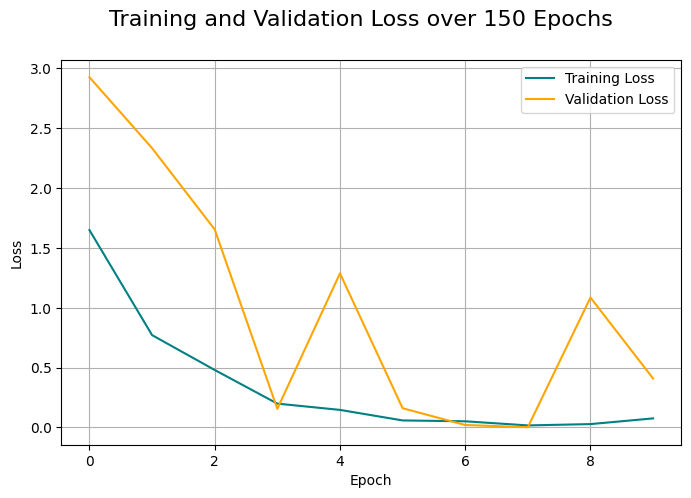

In [5]:
fig = plt.figure(figsize=(8, 5))
plt.plot(hist.history['loss'], color='teal', label='Training Loss')
plt.plot(hist.history['val_loss'], color='orange', label='Validation Loss')
fig.suptitle('Training and Validation Loss over 150 Epochs', fontsize=16)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()


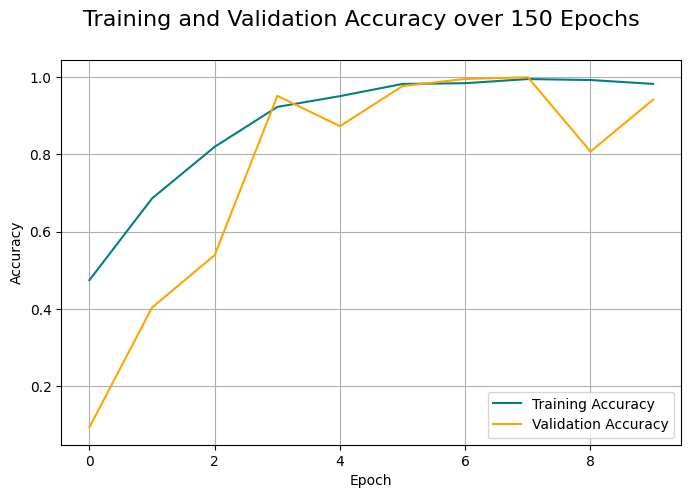

In [6]:
fig = plt.figure(figsize=(8, 5))
plt.plot(hist.history['accuracy'], color='teal', label='Training Accuracy')
plt.plot(hist.history['val_accuracy'], color='orange', label='Validation Accuracy')
fig.suptitle('Training and Validation Accuracy over 150 Epochs', fontsize=16)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

Found 568 files belonging to 10 classes.
Đã phát hiện 10 class: ['cam di nguoc chieu', 'cam do xe', 'cam dung va do xe', 'cam queo phai', 'cam xe oto tai', 'cam xe oto tai va may keo ro-mooc', 'giao nhau voi duong khong uu tien', 'hieu lenh huong di phai', 'toc do toi da 50 kmH', 'toc do toi da 60 kmH']
Tổng cộng: 568 ảnh trong dataset.


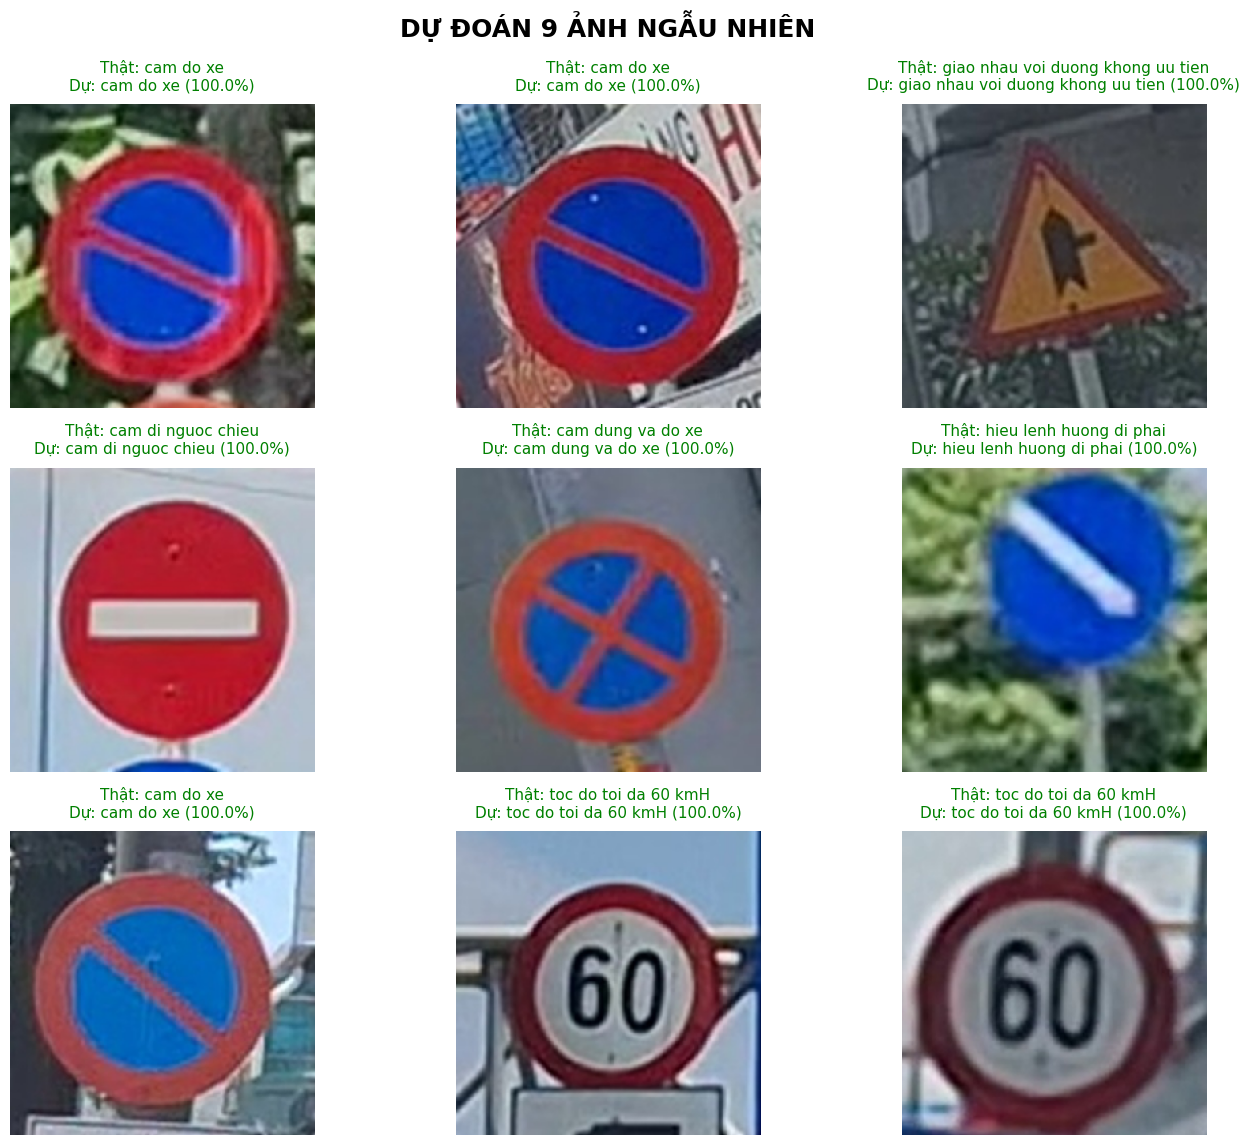

In [9]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import random
from tensorflow.keras.preprocessing import image

# -------------------------------
# 1. TẢI DATASET & LẤY class_names TRƯỚC KHI MAP
# -------------------------------
data_dir = "C:\\Users\\nguye\\Downloads\\dataset"

raw_data = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    image_size=(224, 224),
    batch_size=32,
    label_mode='categorical'
)

# LẤY class_names NGAY TẠI ĐÂY
class_names = raw_data.class_names
print(f"Đã phát hiện {len(class_names)} class: {class_names}")

# Chuẩn hóa dataset
data = raw_data.map(lambda x, y: (x / 255.0, y))

# -------------------------------
# 2. LẤY TẤT CẢ ĐƯỜNG DẪN ẢNH + NHÃN THẬT
# -------------------------------
all_images = []
for class_name in os.listdir(data_dir):
    class_path = os.path.join(data_dir, class_name)
    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            if img_name.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff')):
                img_path = os.path.join(class_path, img_name)
                all_images.append((img_path, class_name))

print(f"Tổng cộng: {len(all_images)} ảnh trong dataset.")

# -------------------------------
# 3. CHỌN NGẪU NHIÊN 9 ẢNH (không trùng)
# -------------------------------
random_images = random.sample(all_images, 9)

# -------------------------------
# 4. TẠO LƯỚI 3x3 ĐỂ HIỂN THỊ
# -------------------------------
plt.figure(figsize=(14, 12))  # Tăng kích thước cho rõ

for i, (img_path, true_label) in enumerate(random_images):
    # Load ảnh
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Dự đoán
    pred = model.predict(img_array, verbose=0)
    pred_idx = np.argmax(pred[0])
    pred_label = class_names[pred_idx]
    confidence = pred[0][pred_idx]

    # Vẽ ảnh
    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.axis('off')

    # Màu tiêu đề
    color = 'green' if pred_label == true_label else 'red'

    plt.title(
        f"Thật: {true_label}\n"
        f"Dự: {pred_label} ({confidence:.1%})",
        color=color,
        fontsize=11,
        pad=10
    )

plt.suptitle("DỰ ĐOÁN 9 ẢNH NGẪU NHIÊN", fontsize=18, fontweight='bold', y=0.95)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
